# Анализ производных признаков


Цель данного ноутбука - проверить распределения, пропуски и аналитическую полезность производных признаков, сформированных на предыдущем этапе.


## Загрузка библиотек и установка настроек


In [20]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка аналитического набора данных


In [21]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Служебные структуры


In [22]:
NUMERIC_COLUMNS = [
    "availability_ratio",
    "review_intensity",
]

CATEGORICAL_COLUMNS = [
    "has_last_review",
    "has_price",
    "is_price_outlier",
    "host_size_segment",
]


In [23]:
featured_listings = listings[NUMERIC_COLUMNS + CATEGORICAL_COLUMNS]


### Проверка пропусков производных признаков


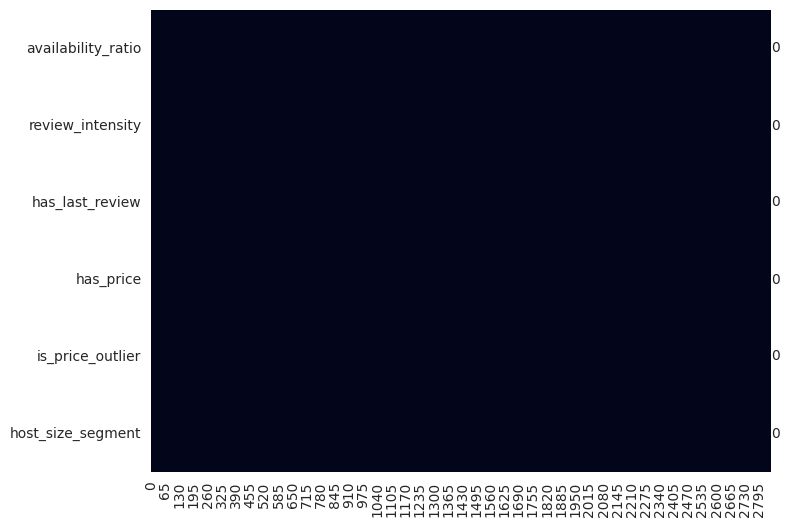

In [24]:
missing_counts = featured_listings.isna().sum()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(featured_listings.isna().T, cbar=False, ax=ax)

for i, val in enumerate(missing_counts):
    ax.text(featured_listings.shape[0], i + 0.5, val, va="center")

plt.show()


Все производные признаки, заполнены полностью.   


## Одномерный анализ производных признаков


### Числовые производные признаки


#### Распределения и базовые статистики


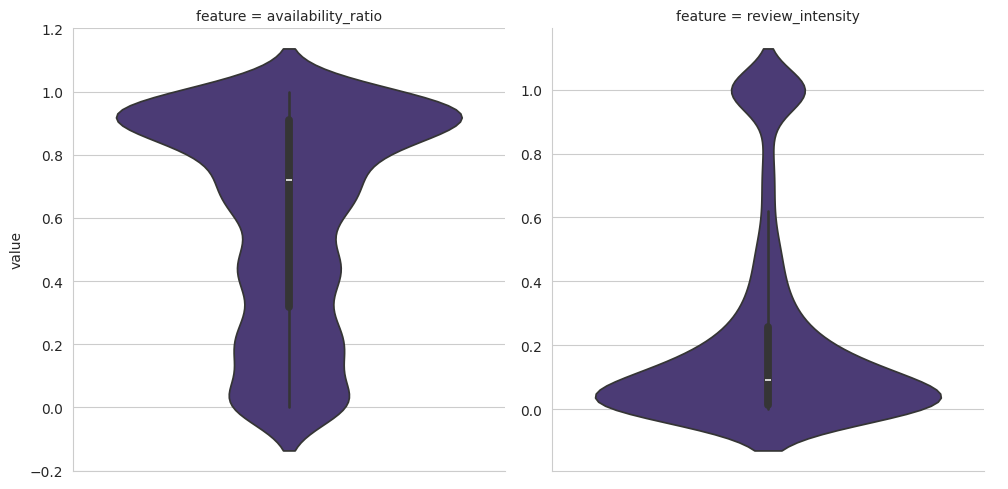

In [25]:
sns.catplot(
    data=featured_listings[NUMERIC_COLUMNS].melt(
        var_name="feature", value_name="value"
    ),
    y="value",
    kind="violin",
    col="feature",
    col_wrap=2,
    sharey=False,
)


In [26]:
listings[NUMERIC_COLUMNS].describe()


,availability_ratio,review_intensity
count,2852.0000,2852.0000
mean,0.6125,0.2270
std,0.3349,0.3159
min,0.0000,0.0000
25%,0.3178,0.0135
50%,0.7205,0.0927
75%,0.9096,0.2585
max,1.0000,1.0000


`availability_ratio` смещено к высоким значениям: большинтво объектов доступны круглый год.   
`review_intensity` для основной массы объектов остаётся низким.     
    


#### Экстремальные наблюдения


In [27]:
for col in [
    "availability_ratio",
    "review_intensity",
]:
    print(f"\n{col} TOP 5")
    display(listings.nlargest(5, col))

    print(f"{col} BOTTOM 5")
    display(listings.nsmallest(5, col))



availability_ratio TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
45,2569529,Downtown Asheville 2 bed/2bath unit for rent,8671251,Heather,28801,35.6011,-82.5559,Entire home/apt,85.0000,180,...,0.0700,1,365,0,True,True,False,Individual host,1.0000,0.0000
55,3445336,Bungalow in Downtown Asheville,17363326,Michael,28801,35.5918,-82.5463,Entire home/apt,NaN,30,...,NaN,2,365,0,False,False,False,Experienced host,1.0000,0.0000
109,7001873,Wren's Nest Studio near River Arts,11298793,Miriam,28806,35.5950,-82.5886,Entire home/apt,69.0000,730,...,3.7300,1,365,0,True,True,False,Individual host,1.0000,0.0000
134,8593492,Cabin 400 sq all for you.,45217605,Gathai,28732,35.4411,-82.5219,Private room,372.0000,2,...,0.4700,2,365,0,True,True,False,Experienced host,1.0000,0.0000
244,15845920,The Treehouse Below - Private Apartment / Entr...,46300912,Robin,28806,35.5723,-82.6049,Entire home/apt,270.0000,1,...,0.2300,1,365,0,True,True,False,Individual host,1.0000,0.0000


availability_ratio BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,35.6015,-82.5604,Entire home/apt,NaN,2,...,2.5300,3,0,0,True,False,False,Experienced host,0.0000,0.0000
26,1332684,Sweet Studio - Walk West Asheville,2799158,Kari,28806,35.5818,-82.5927,Entire home/apt,NaN,30,...,3.4700,1,0,2,True,False,False,Individual host,0.0000,0.0039
50,3225871,Little forest 5 mins from airport,16293519,Chun,28732,35.4410,-82.5057,Entire home/apt,NaN,1,...,0.7800,1,0,0,True,False,False,Individual host,0.0000,0.0000
54,3405282,The Cabin In Grove Park,17173574,Scott & Catherine,28801,35.6121,-82.5441,Entire home/apt,NaN,30,...,0.2000,1,0,0,True,False,False,Individual host,0.0000,0.0000
81,5344892,Peaceful Mountainside Living,5912974,Daniel,28805,35.6245,-82.4934,Entire home/apt,NaN,30,...,1.6700,1,0,0,True,False,False,Individual host,0.0000,0.0000



review_intensity TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
1275,50420851,Walk to Downtown; Great outdoor living space,2027413,Meg,28804,35.6058,-82.5422,Entire home/apt,184.0000,2,...,0.3700,1,100,2,True,True,False,Individual host,0.2740,1.0000
1449,54065879,Fresh and Humble,3947707,Cristina,28803,35.5659,-82.5303,Entire home/apt,100.0000,15,...,0.2300,1,356,2,True,True,False,Individual host,0.9753,1.0000
1735,718734312042377715,Paris of the South - Walkable West AVL Studio,24165374,Maria,28806,35.5698,-82.5717,Entire home/apt,74.0000,1,...,3.9300,1,227,48,True,True,False,Individual host,0.6219,1.0000
1800,776014861241735902,The Nest | Home Office & 5 Min. to Downtown AVL!,10603047,Caleb,28805,35.5903,-82.5369,Entire home/apt,109.0000,1,...,0.0900,11,63,1,True,True,False,Industrial host,0.1726,1.0000
1823,793310877280708097,Davenport Cottage | Pet Friendly | Walk to Town,10603047,Caleb,28806,35.5713,-82.5983,Entire home/apt,281.0000,2,...,0.0800,11,76,1,True,True,False,Industrial host,0.2082,1.0000


review_intensity BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
3,246315,Asheville Dreamer's Cabin,1292070,Annie,28805,35.5962,-82.5063,Private room,62.0000,7,...,0.3100,3,70,0,True,True,False,Experienced host,0.1918,0.0000
5,427497,Luxurious Mountain Guest Suite Apartment,1909922,Milan,28803,35.4909,-82.4860,Entire home/apt,148.0000,2,...,0.3000,1,359,0,True,True,False,Individual host,0.9836,0.0000
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,35.6015,-82.5604,Entire home/apt,NaN,2,...,2.5300,3,0,0,True,False,False,Experienced host,0.0000,0.0000
12,723349,#2 Blue Ridge Room at Oakland Cottage B&B,3736218,Mary,28801,35.5747,-82.5571,Private room,247.0000,2,...,0.1000,7,325,0,True,True,False,Industrial host,0.8904,0.0000
15,846221,Town and Mountain Peaceful Retreat,4418555,Bart,28804,35.6436,-82.5114,Entire home/apt,169.0000,2,...,0.8200,1,178,0,True,True,False,Individual host,0.4877,0.0000


Экстремумы показывают три разных типа поведения.    
`availability_ratio` принимает значения от полной недоступности до доступности весь год;    
`review_intensity` достигает *1* у объявлений, чьи все накопленные отзывы пришлись на последний год;    


### Категориальные производные признаки


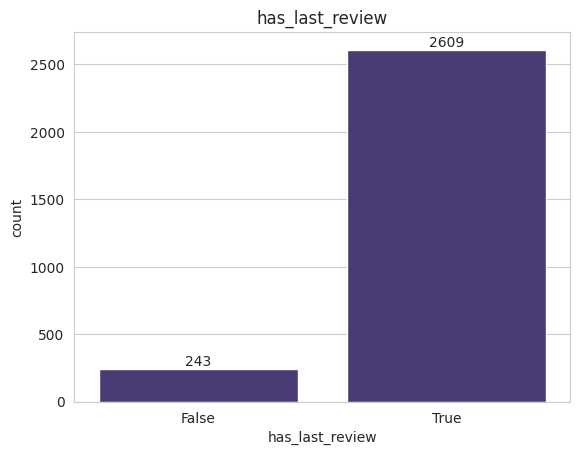

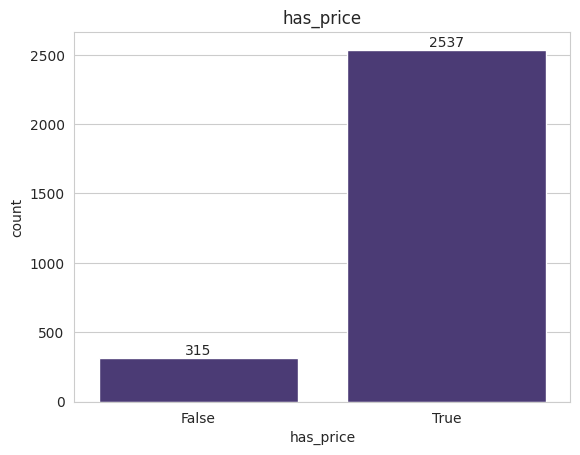

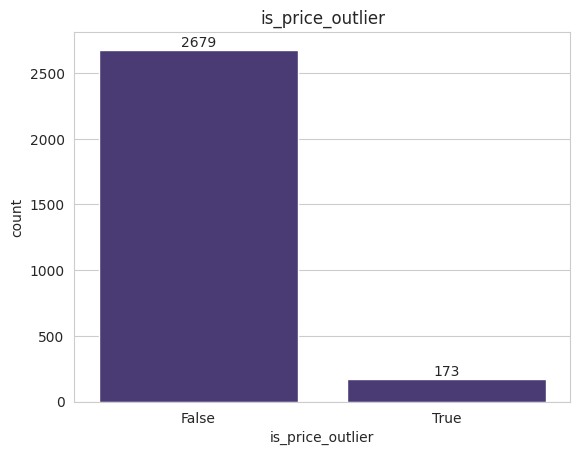

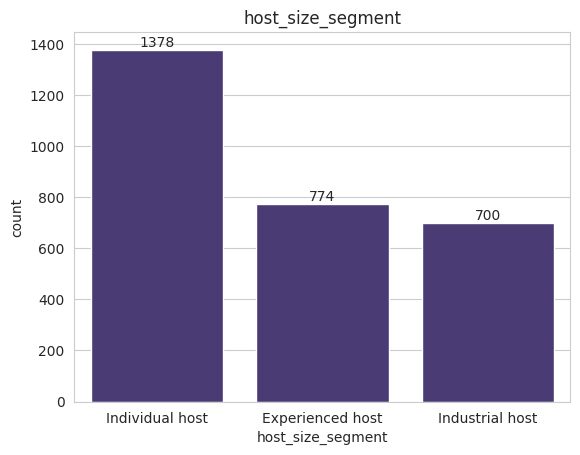

In [28]:
for col in CATEGORICAL_COLUMNS:
    ax = sns.countplot(data=listings, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col)
    plt.show()


Категориальные производные поля остаются интерпретируемыми и достаточно информативными.


## Промежуточные выводы
1. Производные признаки пригодны для дальнейшего анализа и заполнены полностью.
2. `is_price_outlier` отделяет 173 наблюдения верхнего ценового хвоста, поэтому downstream-ноутбуки могут анализировать выбросы отдельно без потери строк.
3. `availability_ratio`, `review_intensity` и `host_size_segment` остаются интерпретируемыми и достаточно вариативными.
